In [1]:
import numpy as np
from monodromy.haar import expected_cost
from monodromy.render import _plot_coverage_set
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.circuit.library import (
    CXGate,
    RZXGate,
    SwapGate,
    UGate,
    UnitaryGate,
    XXPlusYYGate,
    iSwapGate,
)
from qiskit.circuit.random import random_circuit
from qiskit.quantum_info import Operator, average_gate_fidelity
from qiskit.quantum_info.random import random_unitary
from qiskit.transpiler import (
    InstructionProperties,
    PassManager,
    Target,
    generate_preset_pass_manager,
)
from qiskit.transpiler.passes import Optimize1qGatesDecomposition
from tqdm import trange, tqdm
from weylchamber import c1c2c3

from gulps.gulps_decomposer import GulpsDecomposer
from gulps.synthesis_pass import GulpsDecompositionPass
from gulps.utils.invariants import GateInvariants
from gulps.utils.isa import expected_costs
from gulps.utils.visualize import render_path

# from gulps.synthesis_plugin import GulpsSynthesisPlugin

In [2]:
from gulps.utils.logging_config import logger

logger.setLevel("INFO")
# logger.setLevel("DEBUG")

In [7]:
# NOTE, this is expensive but typically you wouldn't need to built all these at once
# either turn precompute_polytope off or
# just save the circuitpolytope data and not go through the expensive build repeatedly
from gulps.isa_library.defined_isas import ISA_LIBRARY

[gulps.isa_library.defined_isas] INFO: Building ISA: iswap_5


[gulps.isa_library.defined_isas] INFO:   → Coverage set built in 3.25 seconds
[gulps.isa_library.defined_isas] INFO:   → Expected (Cost: 0.94, Depth: 4.71, Polytope Index: 4.708019938457598)
[gulps.isa_library.defined_isas] INFO: Building ISA: iswap_4
[gulps.isa_library.defined_isas] INFO:   → Coverage set built in 2.69 seconds
[gulps.isa_library.defined_isas] INFO:   → Expected (Cost: 0.96, Depth: 3.84, Polytope Index: 3.8395746639269444)
[gulps.isa_library.defined_isas] INFO: Building ISA: iswap_3
[gulps.isa_library.defined_isas] INFO:   → Coverage set built in 2.24 seconds
[gulps.isa_library.defined_isas] INFO:   → Expected (Cost: 0.99, Depth: 2.97, Polytope Index: 2.9719359276565713)
[gulps.isa_library.defined_isas] INFO: Building ISA: iswap_3_5
[gulps.isa_library.defined_isas] INFO:   → Coverage set built in 18.23 seconds
[gulps.isa_library.defined_isas] INFO:   → Expected (Cost: 0.89, Depth: 3.36, Polytope Index: 9.305296232601426)
[gulps.isa_library.defined_isas] INFO: Building 

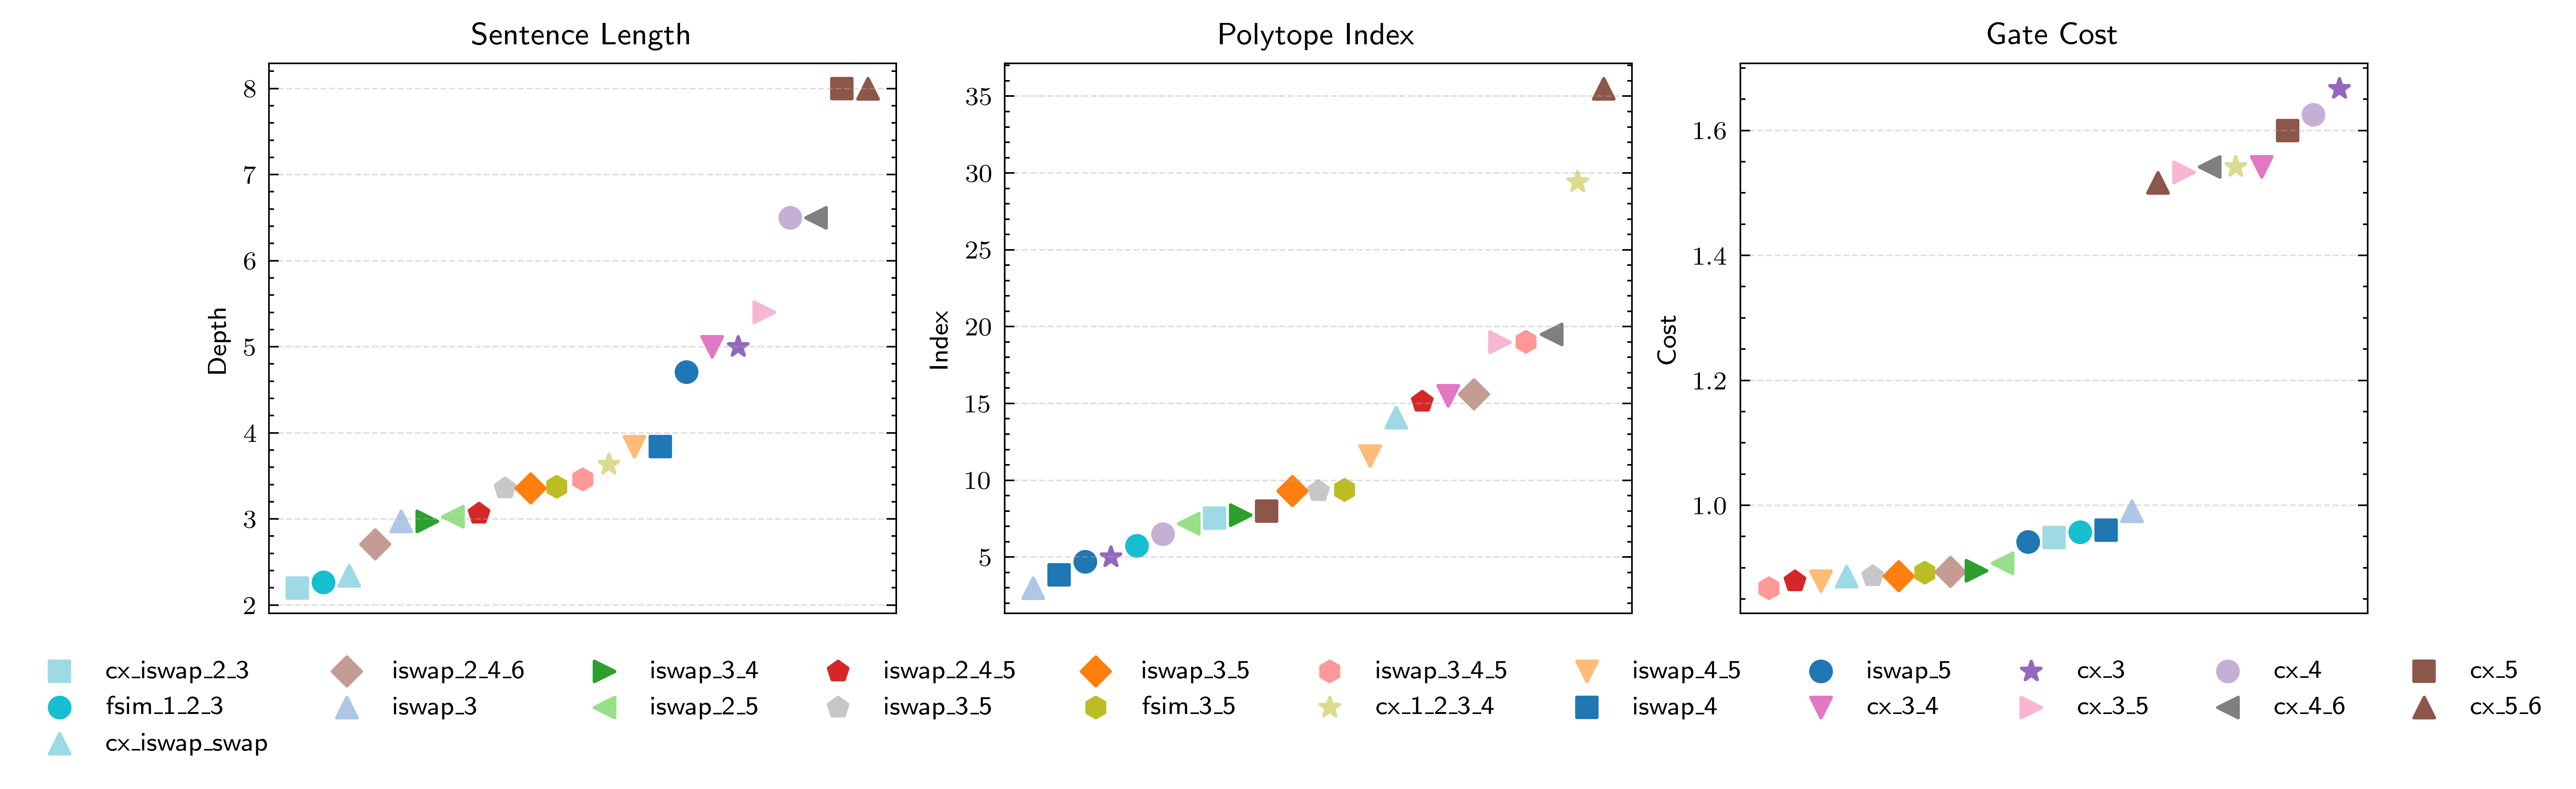

In [8]:
import lovelyplots
import scienceplots
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

# Extract ISA info
names = [cfg["name"] for cfg in ISA_LIBRARY]
haar = np.array([cfg["expected_cost"] for cfg in ISA_LIBRARY])
depth = np.array([cfg["expected_sentence_len"] for cfg in ISA_LIBRARY])
poly = np.array([cfg["expected_polytope_index"] for cfg in ISA_LIBRARY])

# Assign consistent colors/markers to ISAs
N = len(names)
colors = cm.tab20(np.linspace(0, 1, N))
markers = ["o", "s", "^", "D", "v", ">", "<", "p", "h", "*"] * ((N // 10) + 1)

# Prepare sorting per metric
sorted_depth = np.argsort(depth)
sorted_poly = np.argsort(poly)
sorted_haar = np.argsort(haar)

with plt.style.context(["ieee", "science", "use_mathtext"]):
    fig, axes = plt.subplots(1, 3, figsize=(9.5, 2.8))

    for idx, (vals, sort_idx, title, ylabel, ax) in enumerate(
        zip(
            [depth, poly, haar],
            [sorted_depth, sorted_poly, sorted_haar],
            ["Sentence Length", "Polytope Index", "Gate Cost"],
            ["Depth", "Index", "Cost"],
            axes,
        )
    ):
        for i, j in enumerate(sort_idx):
            ax.scatter(
                i, vals[j], c=[colors[j]], marker=markers[j], s=40, label=names[j]
            )
        ax.set_title(title)
        ax.set_ylabel(ylabel)
        ax.set_xticks([])
        ax.grid(True, axis="y", linestyle="--", alpha=0.4)
    # show legend once, center bottom of the figure
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=len(names) / 2,
        bbox_to_anchor=(0.5, -0.2),
    )
    fig.tight_layout()
plt.show()


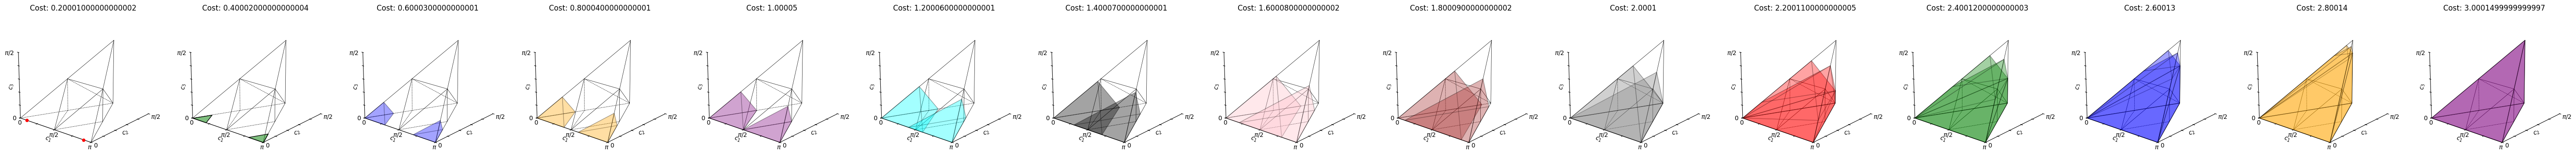

(np.float64(1.6000839515284633), np.float64(8.000019756654483), np.float64(8.000019756654483))


In [ ]:
def fsim(theta, phi):
    _fsim = QuantumCircuit(2, name="fsim")
    _fsim.append(XXPlusYYGate(2 * theta), [0, 1])
    _fsim.cp(phi, 0, 1)
    return _fsim.to_gate()


# comment out what you don't want or add your own
isa = [
    # (CXGate(), 1.0, "cx"),
    (CXGate().power(1 / 5), 1 / 5, "sqrt5cx"),
    (CXGate().power(1 / 6), 1 / 6, "sqrt6cx"),
    # (iSwapGate(), 1.0, "iswap"),
    # (iSwapGate().power(1 / 2), 1 / 2, "sqrt2iswap"),
    # (iSwapGate().power(1 / 3), 1 / 3, "sqrt3iswap"),
    # (iSwapGate().power(1 / 4), 1 / 4, "sqrt4iswap"),
    # (fsim(np.pi / 2, np.pi / 6).power(1.0), 1.0, "fsim"),
    # (fsim(np.pi / 2, np.pi / 6).power(1 / 2), 1 / 2, "sqrt2fsim"),
    # (fsim(np.pi / 2, np.pi / 6).power(1 / 3), 1 / 3, "sqrt3fsim"),
    # (SwapGate(), 0.0, "swap"),
]
gate_set, costs, names = zip(*isa)
decomposer = GulpsDecomposer(gate_set=gate_set, costs=costs, names=names)
if hasattr(decomposer.isa, "coverage_set"):
    _plot_coverage_set(decomposer.isa.coverage_set)
    print(expected_costs(decomposer.isa.coverage_set))

In [4]:
# warmstart
u = random_unitary(4, seed=984)
v = Operator(decomposer(u))

In [5]:
logger.setLevel("INFO")
N = 1000
fidelities = []
all_timings = []

for idx in trange(N):
    u = random_unitary(4, seed=idx)
    v = Operator(decomposer(u))
    fid = average_gate_fidelity(u, v)
    fidelities.append(fid)
    all_timings.append(decomposer.last_timing)

    if fid < 1 - 1e-6:
        print(f"Unitary {idx} fidelity is low: {fid:.8f}")
        print("Canonical invariants:")
        print("U:", c1c2c3(u))
        print("V:", c1c2c3(v))
        print("\n")
        continue

# Summary statistics
fidelities = np.array(fidelities)
print(f"\nSummary across {len(fidelities)} samples:")
print(f"  Median fidelity: {np.median(fidelities)}")
print(f"  Mean fidelity:   {np.mean(fidelities)}")
print(f"  Minimum fidelity:{np.min(fidelities)}")


# Convert list of dicts to array for easier aggregation
phase_names = list(all_timings[0].keys())
timing_array = np.array([[t[k] for k in phase_names] for t in all_timings])
phase_means = dict(zip(phase_names, np.mean(timing_array, axis=0)))
total_means = np.mean(timing_array.sum(axis=1))

print("\nAverage timings:")
for k, v in phase_means.items():
    print(f"  {k}: {v:.4f} seconds")
print(f"\nTotal average time: {total_means:.4f} seconds")

  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [00:37<00:00, 26.88it/s]


Summary across 1000 samples:
  Median fidelity: 1.0
  Mean fidelity:   0.9999999999826391
  Minimum fidelity:0.9999999973202012

Average timings:
  lp: 0.0005 seconds
  numeric: 0.0344 seconds
  stitch: 0.0011 seconds

Total average time: 0.0361 seconds


In [10]:
logger.setLevel("DEBUG")
# logger.setLevel("INFO")
isa = [
    (iSwapGate().power(1 / 4), 1 / 4, "sqrt4iswap"),
]
gate_set, costs, names = zip(*isa)
decomposer = GulpsDecomposer(gate_set=gate_set, costs=costs, names=names)

hard_seeds = [984, 573, 781, 244, 217, 324, 627, 690, 117]
for seed in tqdm([217]):
    target_unitary = random_unitary(4, seed=seed)
    output_circuit = decomposer._run(target_unitary, log_output=False)

    fidelity = average_gate_fidelity(Operator(target_unitary), Operator(output_circuit))
    assert fidelity > 1 - 1e-6, f"Fidelity too low at seed {seed}: {fidelity}"
    assert decomposer.last_timing["numeric"] < 1.0, (
        f"Numeric timing too high at seed {seed}: {decomposer.last_timing['numeric']:.4f} seconds"
    )

  0%|          | 0/1 [00:00<?, ?it/s][gulps.gulps_decomposer] DEBUG: Sentence: ['sqrt4iswap', 'sqrt4iswap', 'sqrt4iswap', 'sqrt4iswap']
[gulps.gulps_decomposer] DEBUG: Intermediates: [(np.float64(0.12500000000000003), np.float64(0.0), np.float64(0.0), np.float64(-0.12500000000000003)), (np.float64(0.22557630641710463), np.float64(0.005843050900836838), np.float64(-0.0), np.float64(-0.23141935731794147)), (np.float64(0.34618054804791), np.float64(0.005843050900836838), np.float64(0.0043957583691946744), np.float64(-0.3564193573179415)), (np.float64(0.34618054804791), np.float64(0.13084305090083687), np.float64(0.004395758369194678), np.float64(-0.4814193573179416))]
[gulps.local_numerics] DEBUG: [EASY 1/8] residual=[ 3.30869156e-05 -2.08549931e-07 -1.61150960e-05] (‖residual‖=6.77e-10, nfev=128)
[gulps.local_numerics] DEBUG: [EASY 2/8] residual=[ 3.21837412e-09  2.11512320e-10 -2.21731633e-09] (‖residual‖=7.66e-18, nfev=46)
[gulps.local_numerics] DEBUG: => Success on [EASY 2] (component

AssertionError: Numeric timing too high at seed 217: 1.2286 seconds